<a href="https://colab.research.google.com/github/Luiz-Frederico/lfncampelo_pbl_fase5/blob/main/Luiz_Frederico_rm567319_pbl_fase5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports


In [1]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors


# Modelos de regressão serão importados nas células de modelagem ao final.

# Análise Exploratória do Dados  (EDA)

In [2]:
# Carregamento dos dados

df = pd.read_csv('crop_yield.csv')
df.head()

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


In [3]:
# Visualização das primeiras linhas e informações gerais
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


In [4]:
df.describe()

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


In [5]:
# Verificação de valores nulos
print(f"Valores ausentes:\n{df.isnull().sum()}")


# Layout de confirmação
print('-' * 41)
print('=' * 38)
if df.isnull().sum().sum() == 0:
    print("A base não apresenta valores ausentes!")
else:
    print("Existem valores ausentes na base!")
print('=' * 38)

Valores ausentes:
Crop                                    0
Precipitation (mm day-1)                0
Specific Humidity at 2 Meters (g/kg)    0
Relative Humidity at 2 Meters (%)       0
Temperature at 2 Meters (C)             0
Yield                                   0
dtype: int64
-----------------------------------------
A base não apresenta valores ausentes!


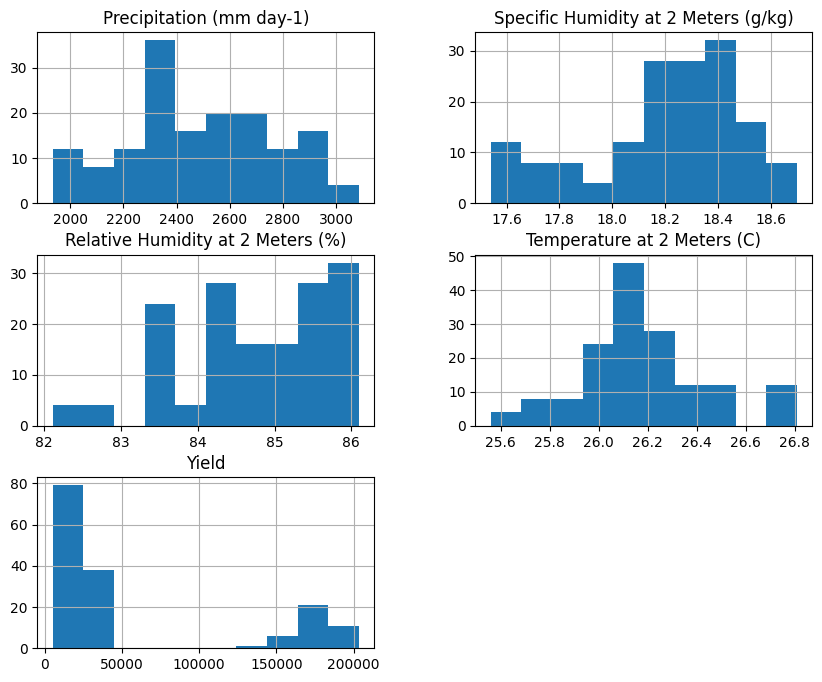

In [6]:
df.hist(figsize=(10,8))
plt.show()

# Correlação das features


<small>**Importante:** A matriz de correlação foi construída utilizando apenas variáveis numéricas, pois o coeficiente de correlação de Pearson é definido para dados quantitativos contínuos. A variável categórica Crop foi analisada separadamente por meio da comparação de rendimento médio entre culturas.

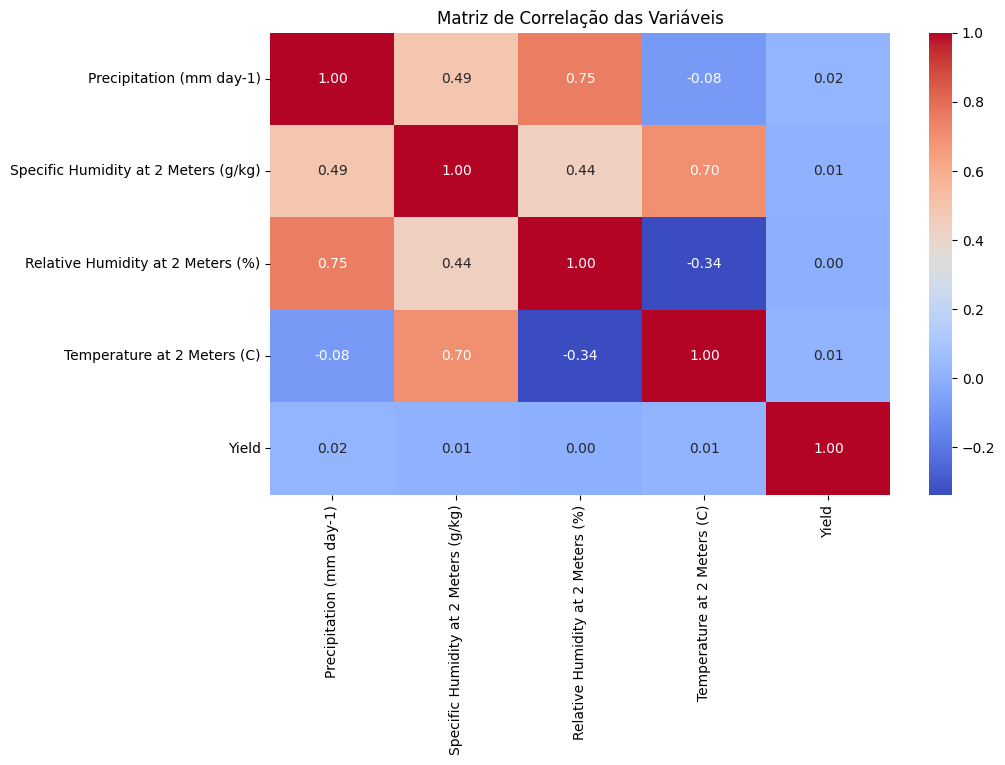

In [7]:
#Matriz de Correlação
# Selecionar apenas variáveis numéricas
df_numeric = df.select_dtypes(include=['int64', 'float64'])

# Calcular matriz de correlação
corr_matrix = df_numeric.corr()

# Criar o gráfico
plt.figure(figsize=(10,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
)

plt.title("Matriz de Correlação das Variáveis")
plt.show()





Análise Variavél 'Crop'(Média de produtividade)


In [8]:
print('=' * 31)

resultado = df.groupby("Crop")["Yield"].mean().sort_values(ascending=False).reset_index()
print(f'{"Crop":<20} {"Yield":>10}')
print("-"*30)
for _, row in resultado.iterrows():
    print(f'{row["Crop"]:<20} {row["Yield"]:>10.3f}')
print('=' * 31)

Crop                      Yield
------------------------------
Oil palm fruit       175804.692
Rice, paddy           32099.667
Cocoa, beans           8883.128
Rubber, natural        7824.897


Oil Palm █████████████████

Rice --- ███████

Cocoa - ████

Rubber- ███



Text(0.5, 1.0, 'Distribuição do Rendimento')

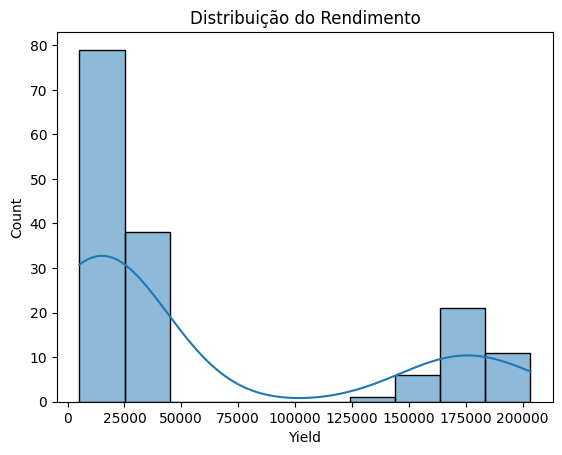

In [9]:
sns.histplot(df['Yield'], kde=True)
plt.title("Distribuição do Rendimento")

# Identificação de Outliers via Boxplots

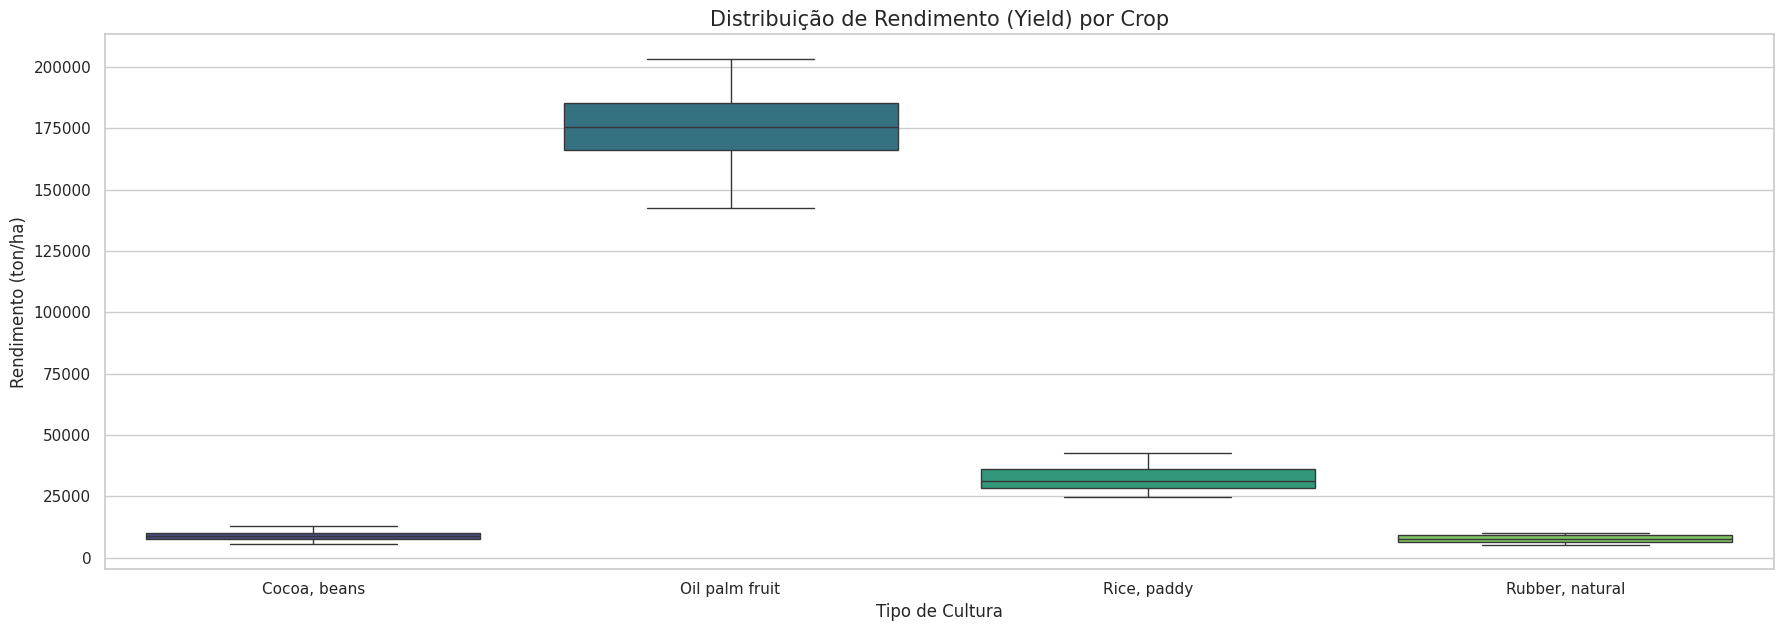

In [10]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 12))

# 1. Boxplot de Yield por Crop
plt.subplot(2, 1, 1)
sns.boxplot(x='Crop', y='Yield', data=df, hue='Crop', palette='viridis', legend=False)
plt.title('Distribuição de Rendimento (Yield) por Crop', fontsize=15)
plt.xlabel('Tipo de Cultura', fontsize=12)
plt.ylabel('Rendimento (ton/ha)', fontsize=12)

plt.tight_layout()
plt.show()

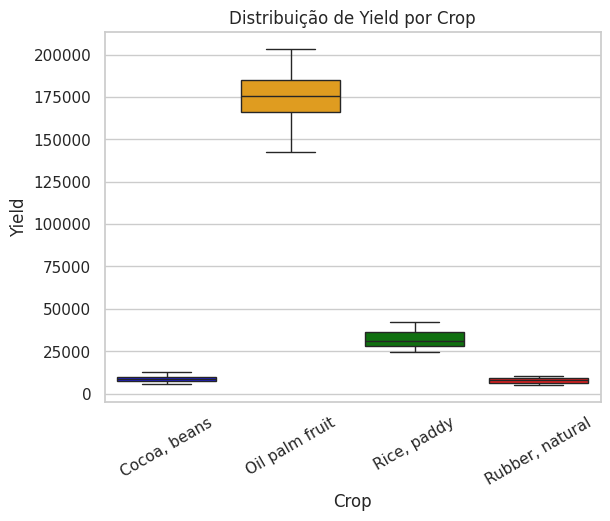

In [11]:

palette_crop = {
    "Cocoa, beans": "blue",
    "Oil palm fruit": "orange",
    "Rice, paddy": "green",
    "Rubber, natural": "red"
}

sns.boxplot(
    data=df,
    x="Crop",
    y="Yield",
    hue="Crop",
    palette=palette_crop,
    legend=False
)

plt.xticks(rotation=30)
plt.title("Distribuição de Yield por Crop")

plt.show()

<small>**Nota:** O boxplot da variável ***Yield*** por cultura revela diferenças significativas na produtividade entre os tipos de cultivo. Algumas culturas apresentam valores médios de rendimento substancialmente maiores, além de maior dispersão dos dados. Isso indica que o tipo de cultura é um fator determinante para a produtividade agrícola, reforçando a importância da codificação da variável categórica Crop no processo de modelagem.

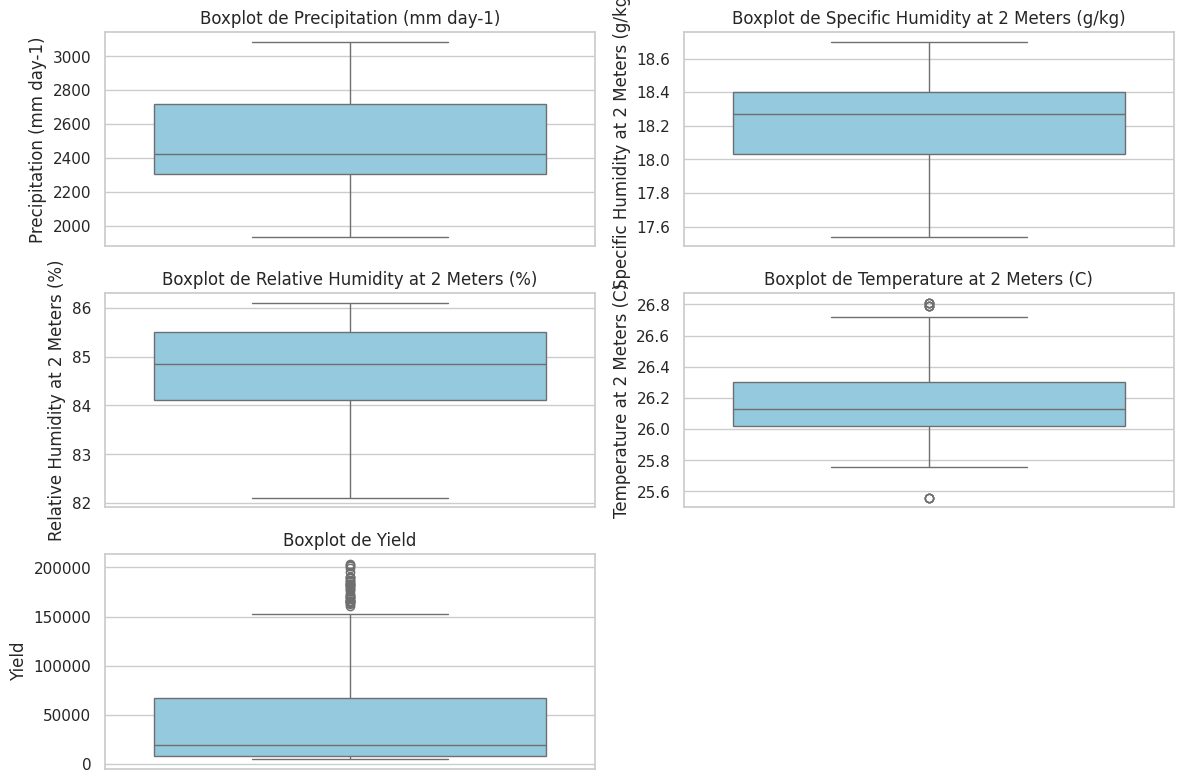

In [12]:
# Boxplots individuais para cada feature (variável numérica)

sns.set_theme(style="whitegrid")

# Selecionar apenas variáveis numéricas
df_numeric = df.select_dtypes(include=['int64', 'float64'])

# Criar figura
plt.figure(figsize=(12,8))

# Loop para criar um boxplot para cada feature
for i, column in enumerate(df_numeric.columns, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(y=df_numeric[column], color='skyblue')
    plt.title(f'Boxplot de {column}')

plt.tight_layout()
plt.show()

<small>**Nota:** Foram construídos boxplots para todas as variáveis numéricas com o objetivo de analisar a distribuição dos dados, identificar possíveis outliers e compreender a dispersão das variáveis climáticas e da produtividade agrícola. Essa análise auxilia na compreensão da variabilidade dos dados antes da aplicação de métodos de clusterização e modelos preditivos.

# Pré-processamento de Dados e Treino/Test

In [13]:
# Preparação Geral (X e y para Regressão Futura)
# Aqui mantemos o y (Yield) ORIGINAL e criamos o X com One-Hot Encoding

X = df.drop(columns=["Yield"])
y = df["Yield"]  # <--- Este é o seu Yield original para a predição!

# Aplicar One-Hot apenas no X
X = pd.get_dummies(X, columns=["Crop"], prefix="Crop")

# Train Test Split(Para a Regressão)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Padronização do X (sem o Yield)
scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)


# Preparação Para Clusterização
# Criamos uma cópia separada para não "sujar" as variáveis acima
features_cluster = [
    "Precipitation (mm day-1)",
    "Specific Humidity at 2 Meters (g/kg)",
    "Relative Humidity at 2 Meters (%)",
    "Temperature at 2 Meters (C)",
    "Yield"
]

# Criamos um scaler específico que vai incluir o Yield
scaler_cluster = StandardScaler()

# Padronizamos o dataset de análise (aqui o Yield é escalado temporariamente)
X_scaled_cluster = scaler_cluster.fit_transform(df[features_cluster])

# Convertemos para DataFrame para facilitar o uso no K-Means
X_scaled_df = pd.DataFrame(X_scaled_cluster, columns=features_cluster)

**Prevenção de Data Leakage no Pré-processamento**

<small>Durante a etapa de preparação dos dados para regressão, foi adotada uma estratégia que evita o problema conhecido como **data leakage**. Esse problema ocorre quando informações do conjunto de teste são utilizadas inadvertidamente durante o treinamento do modelo, o que pode gerar resultados artificialmente otimistas e comprometer a capacidade de generalização do modelo.

<small>Para evitar esse problema, o conjunto de dados foi inicialmente dividido em **dados de treino e teste** utilizando a função **train_test_split**. Em seguida, o processo de padronização das variáveis numéricas foi realizado utilizando *StandardScaler*, sendo o modelo de escala ajustado (**fit**) apenas com os dados de treino (**X_train**). Posteriormente, essa mesma transformação foi aplicada ao conjunto de teste (**X_test**) por meio do método **transform**.

<small>Dessa forma, garante-se que o modelo não tenha acesso a informações estatísticas do conjunto de teste durante o treinamento, preservando a integridade do processo de avaliação e garantindo uma estimativa mais realista do desempenho do modelo.


**Codificação de Variáveis Categóricas(One-Hot Encoding)**

**Padronização das Variáveis Numéricas (StandardScaler)**






<small>**Importante**: Utilização de **One-Hot Encoding** na variável 'Crop' para
permitir que o modelo diferencie as culturas agrícolas sem criar uma hierarquia numérica artificial. As variáveis numéricas possuem escalas diferentes (milhares, dezenas, temperature 20–30), havendo a necessidade de padronização. Algoritmos baseados em distância ou gradiente podem dar mais peso à variável com números maiores.

# Análise geral para descobrir potenciais formas de clusterizar os dados

<small>Para investigar possíveis padrões e agrupamentos naturais entre as variáveis climáticas e o rendimento das culturas, os dados numéricos foram padronizados utilizando **StandardScaler**. A padronização garante que todas as variáveis estejam na mesma escala, evitando que variáveis com maior magnitude influenciem desproporcionalmente análises baseadas em distância. Essa etapa também facilita a visualização e interpretação das relações entre variáveis nos gráficos exploratórios, além de preparar os dados para os métodos de clusterização aplicados nas etapas seguintes.

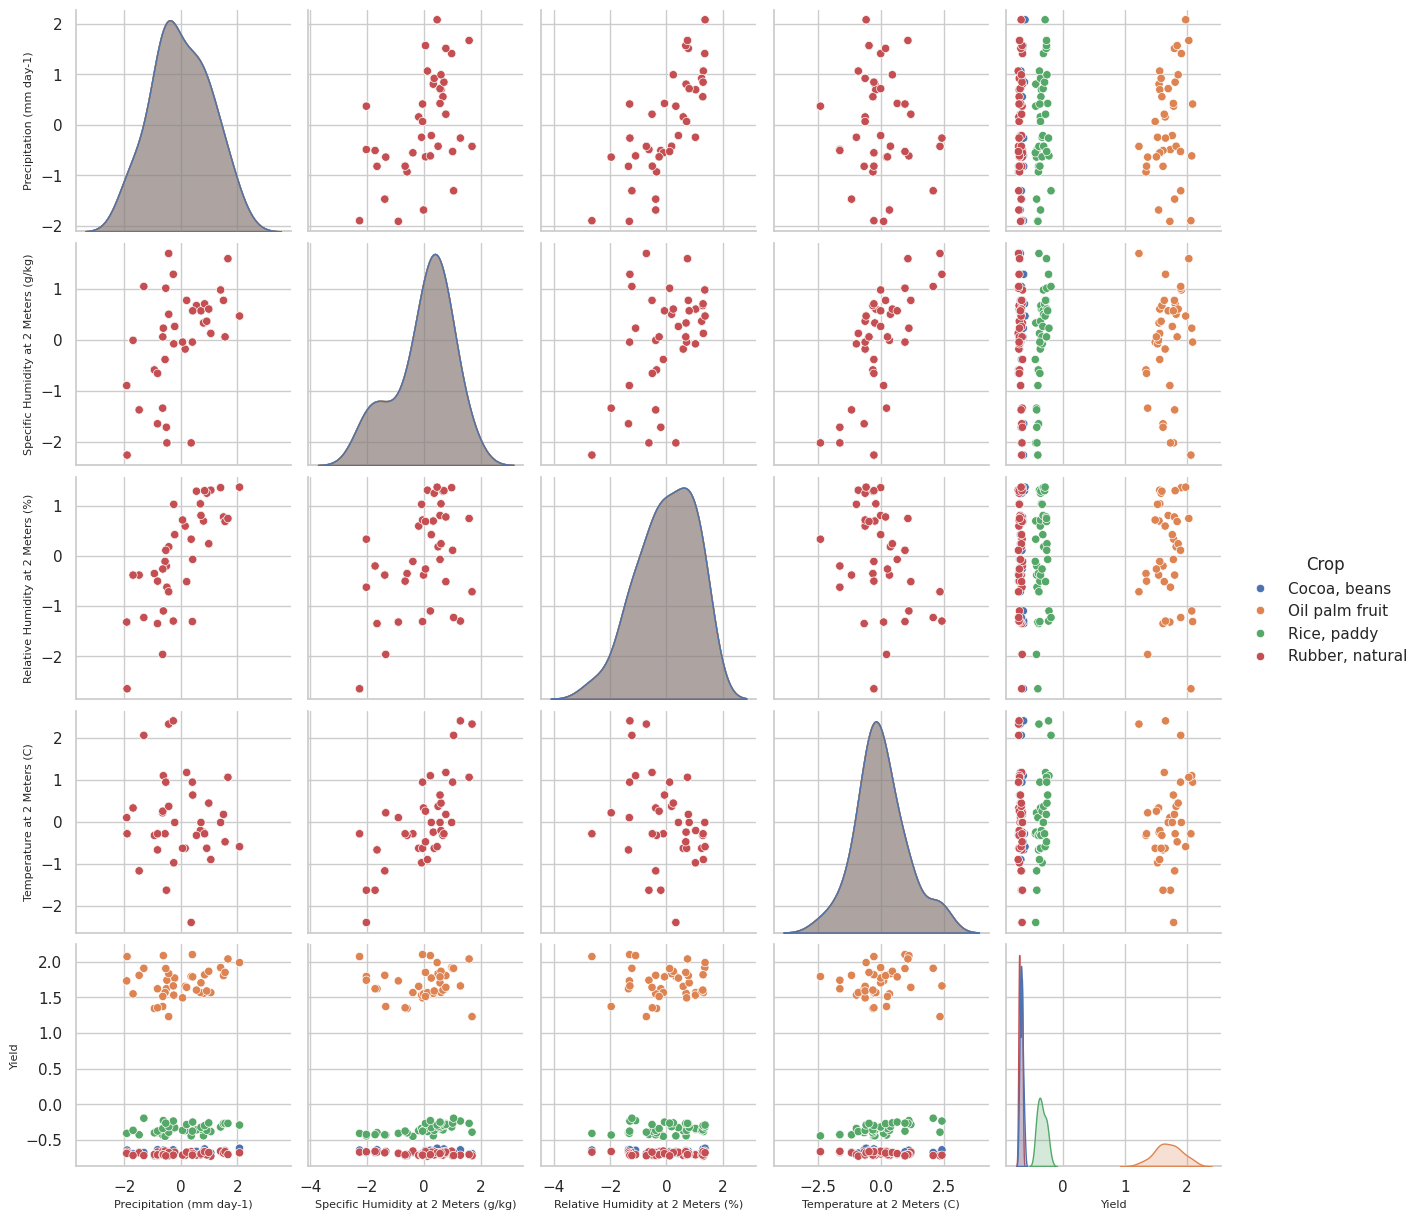

In [14]:
# Criar pairplot usando os dados padronizados para análise exploratória
# Seleciona apenas as colunas numéricas


df_pairplot = X_scaled_df.copy()

# Adicionar a coluna Crop para usar como hue
df_pairplot["Crop"] = df["Crop"]

g = sns.pairplot(
    df_pairplot,
    vars=features_cluster,
    hue="Crop",
    diag_kind="kde"
)

# Ajustar tamanho das labels
for ax in g.axes.flatten():
    if ax is not None:
        ax.set_xlabel(ax.get_xlabel(), fontsize=8)
        ax.set_ylabel(ax.get_ylabel(), fontsize=8)

plt.show()


Os dados sugerem que Yield contribui significativamente para a separação das culturas. Os gráficos mostram grupos bem separados.

# Análise entre as variáveis numéricas para descobrir potenciais formas de clusterizar os dados

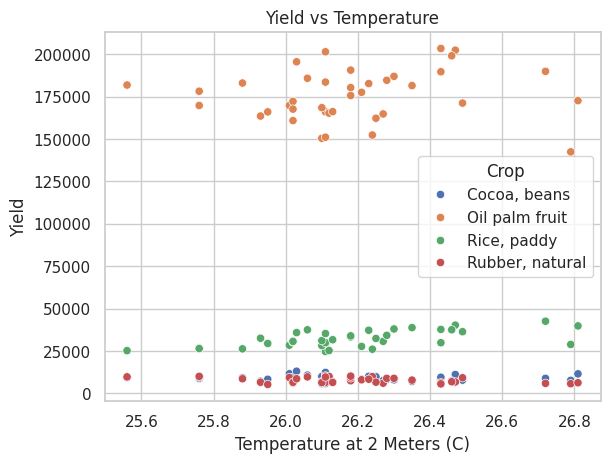

Não há evidência clara de correlação entre temperatura e rendimento.


In [15]:
sns.scatterplot(
    data=df,
    x="Temperature at 2 Meters (C)",
    y="Yield",
    hue="Crop"
)

plt.title("Yield vs Temperature")
plt.show()

print('=' * 68)
print("Não há evidência clara de correlação entre temperatura e rendimento.")
print('=' * 68)

**Análise da relação entre Temperatura e Produtividade (Yield)**

<small>O gráfico de dispersão entre temperatura média e rendimento agrícola mostra que as diferentes culturas se organizam em faixas horizontais bem definidas de produtividade. Observa-se que cada tipo de cultura apresenta um nível típico de rendimento, sendo a cultura de ***Oil palm fruit*** a que apresenta os maiores valores de ***Yield***, seguida por ***Rice, paddy***, enquanto ***Cocoa, beans*** e ***Rubber, natural*** apresentam produtividades menores.

<small>Não foi observada uma tendência crescente ou decrescente clara entre temperatura e rendimento. Os pontos encontram-se distribuídos horizontalmente ao longo do eixo de temperatura, indicando baixa correlação entre essas variáveis no conjunto de dados analisado.

<small>Além disso, a dispersão vertical dos pontos evidencia que a principal fonte de variação do Yield está associada ao tipo de cultura, e não diretamente à temperatura. Esse comportamento sugere que o tipo de cultivo exerce influência mais significativa sobre a produtividade do que pequenas variações térmicas observadas no dataset.

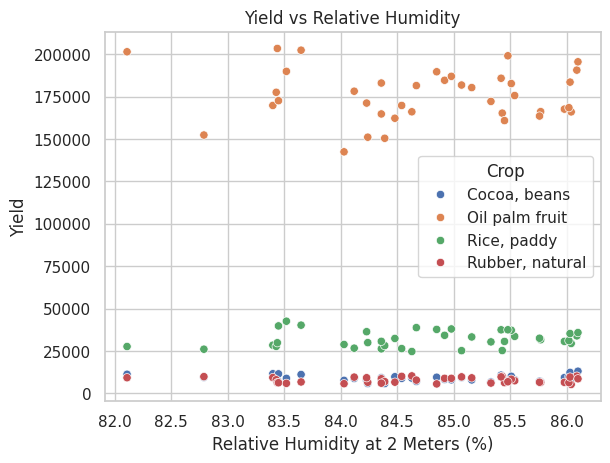

Não há evidência visual de correlação forte entre umidade relativa e rendimento agrícola.


In [16]:
sns.scatterplot(
    data=df,
    x="Relative Humidity at 2 Meters (%)",
    y="Yield",
    hue="Crop"
)

plt.title("Yield vs Relative Humidity")
plt.show()


print('=' * 89)
print("Não há evidência visual de correlação forte entre umidade relativa e rendimento agrícola.")
print('=' * 89)

**Análise da relação entre Umidade Relativa e Produtividade (Yield)**

<small>O gráfico de dispersão entre umidade relativa do ar e rendimento agrícola indica que não há uma tendência crescente ou decrescente clara entre essas variáveis. Os pontos encontram-se distribuídos horizontalmente ao longo do eixo de umidade relativa, sugerindo que pequenas variações nessa variável climática não apresentam relação direta com a produtividade no conjunto de dados analisado.

<small>Observa-se também que os pontos se organizam em faixas horizontais distintas de rendimento, correspondentes aos diferentes tipos de culturas presentes no dataset. A cultura ***Oil palm fruit*** apresenta os maiores valores de produtividade, seguida por ***Rice, paddy***, enquanto ***Cocoa, beans*** e ***Rubber, natural*** apresentam valores menores de ***Yield***.

<small>Além disso, a umidade relativa apresenta baixa variação no conjunto de dados (aproximadamente entre 82% e 86%), o que indica condições climáticas relativamente homogêneas. Esse fator pode limitar a identificação de uma relação mais evidente entre umidade e rendimento agrícola.

<small>Dessa forma, os resultados sugerem que, dentro da faixa de variação observada, o tipo de cultura exerce maior influência sobre o rendimento agrícola do que a umidade relativa do ar.

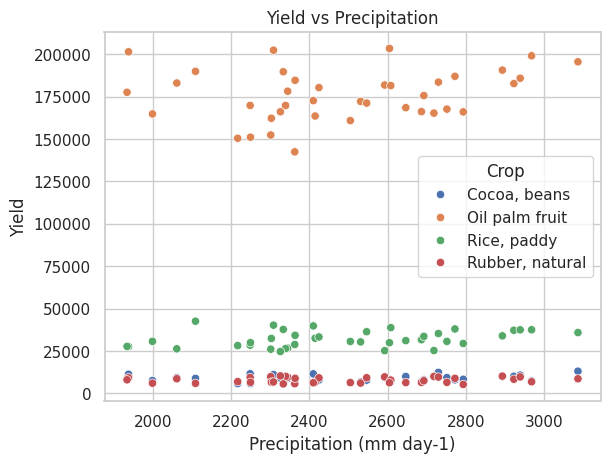

Não existe evidência visual de tendência crescente ou decrescente clara entre precipitação e rendimento agrícola.


In [17]:
sns.scatterplot(
    data=df,
    x="Precipitation (mm day-1)",
    y="Yield",
    hue="Crop",
    )

plt.title("Yield vs Precipitation")
plt.xlabel("Precipitation (mm day-1)")
plt.ylabel("Yield")

plt.show()


print('=' * 113)
print("Não existe evidência visual de tendência crescente ou decrescente clara entre precipitação e rendimento agrícola.")
print('=' * 113)



**Análise da relação entre Precipitação e Produtividade (Yield)**

<small>O gráfico de dispersão entre precipitação e rendimento agrícola indica que não há uma tendência crescente ou decrescente clara entre essas variáveis. Os pontos encontram-se distribuídos ao longo de toda a faixa de precipitação observada, sugerindo que, dentro desse intervalo, a precipitação não apresenta relação direta com o rendimento das culturas.

<small>Observa-se novamente a formação de faixas horizontais bem definidas de produtividade associadas aos diferentes tipos de cultura presentes no dataset. A cultura ***Oil palm fruit*** apresenta os maiores valores de ***Yield***, seguida por ***Rice, paddy***, enquanto ***Cocoa, beans*** e ***Rubber, natural*** apresentam valores menores de produtividade.

<small>Esse padrão indica que o tipo de cultura exerce maior influência sobre o rendimento agrícola do que a precipitação isoladamente. Além disso, a dispersão relativamente uniforme dos pontos ao longo do eixo de precipitação sugere que o conjunto de dados apresenta condições climáticas relativamente semelhantes entre os registros analisados.

<small>**Nota:** Durante análises exploratórias iniciais, a variável ***Yield*** foi momentaneamente considerada
em testes de agrupamento. No entanto, para garantir rigor metodológico e evitar **data leakage**,
a clusterização final foi conduzida exclusivamente com variáveis climáticas.

# K-Means

### Método do Cotovelo (Elbow Method)

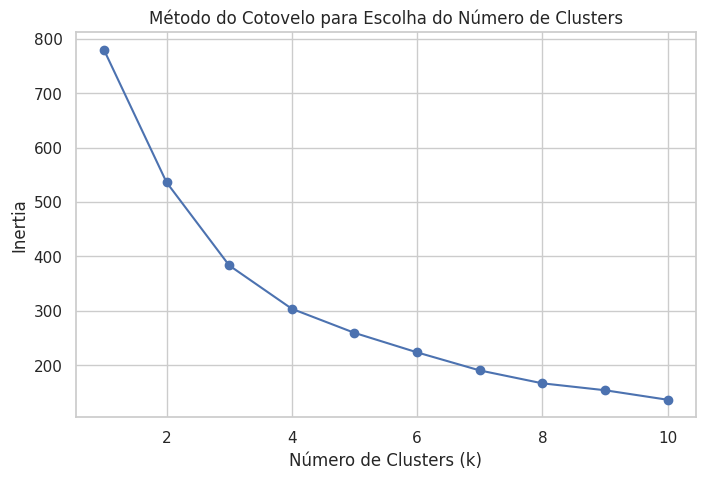

In [18]:
# Método do Cotovelo (Elbow Method)

inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_df)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker='o')

plt.title("Método do Cotovelo para Escolha do Número de Clusters")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Inertia")

plt.show()

**Determinação do Número de Clusters — Método do Cotovelo**

<small>Para determinar o número adequado de clusters para o algoritmo K-Means, foi utilizado o **Método do Cotovelo (Elbow Method)**. Esse método consiste em calcular a **inertia** (soma das distâncias quadráticas entre cada ponto e o centro do seu cluster) para diferentes valores de *k*.

<small>Observa-se que, à medida que o número de clusters aumenta, a inertia diminui, pois os grupos tornam-se mais específicos. No entanto, após determinado ponto, a redução da inertia passa a ocorrer de forma menos significativa.

<small>No gráfico obtido, percebe-se uma redução acentuada da inertia até aproximadamente **k = 4**, a partir do qual as melhorias tornam-se marginais. Esse ponto caracteriza o chamado **“cotovelo” do gráfico**, indicando que quatro clusters representam um bom equilíbrio entre simplicidade do modelo e capacidade de representar a estrutura dos dados.

<small>Dessa forma, o valor **k = 4** foi selecionado para a aplicação do algoritmo K-Means nas etapas seguintes da análise.


In [19]:
# Selecionar apenas variáveis climáticas
features_clima = [
    "Precipitation (mm day-1)",
    "Specific Humidity at 2 Meters (g/kg)",
    "Relative Humidity at 2 Meters (%)",
    "Temperature at 2 Meters (C)"
]

# Criar o scaler
scaler_cluster = StandardScaler()

# Padronizar as variáveis climáticas
X_scaled_cluster = scaler_cluster.fit_transform(df[features_clima])

# Converter para DataFrame mantendo o índice original
X_scaled_df = pd.DataFrame(
    X_scaled_cluster,
    columns=features_clima,
    index=df.index
)

# Visualizar as primeiras linhas
X_scaled_df.head()

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C)
0,-0.823415,-1.648845,-1.347084,-0.667109
1,-1.899565,-2.263223,-2.646141,-0.282807
2,-0.641042,-1.341656,-1.961367,0.216786
3,0.366865,-2.024299,0.334641,-2.396470
4,-0.491386,-2.024299,-0.622029,-1.627865


<small>**Nota:** A exclusão da variável ***Yield*** (rendimento) nas etapas de clusterização é uma medida fundamental para mitigar o vazamento de dados (***data leakage***). Ao fundamentar o agrupamento estritamente em variáveis climáticas, assegura-se que os clusters representem padrões ambientais latentes e independentes. Essa abordagem permite que a análise subsequente da produtividade em relação aos grupos formados possua validade estatística, evitando a circularidade metodológica em que a variável de resposta influenciaria sua própria categorização.

**Utlizar o número de clusters ideias identificados pelo método**

In [20]:
# Aplicar K-Means com 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled_df)

# Adicionar cluster ao dataset original
df["Cluster"] = clusters

# Obtém os centroids do método
centroids = kmeans.cluster_centers_

In [21]:
centroids

array([[-0.2115641 , -1.92190208, -0.16215617, -1.88406665],
       [ 0.85613215,  0.45931668,  0.92108227, -0.24889805],
       [-1.19415852, -1.01929658, -0.99910233, -0.26145695],
       [-0.31721275,  0.71309919, -0.61800091,  1.22365793]])

In [22]:
centroids_df = pd.DataFrame(
    centroids,
    columns=features_clima
)

centroids_df.index = ["Cluster 0", "Cluster 1", "Cluster 2", "Cluster 3"]

centroids_df



,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C)
Cluster 0,-0.211564,-1.921902,-0.162156,-1.884067
Cluster 1,0.856132,0.459317,0.921082,-0.248898
Cluster 2,-1.194159,-1.019297,-0.999102,-0.261457
Cluster 3,-0.317213,0.713099,-0.618001,1.223658


In [23]:
pd.crosstab(df["Cluster"], df["Crop"])

Crop,"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural"
Cluster,,,,
0,3,3,3,3
1,17,17,17,17
2,9,9,9,9
3,10,10,10,10


<small>**Nota:** Existe um perfeito equilibrio na tabela.

# Visualizar distribuição dos clusters

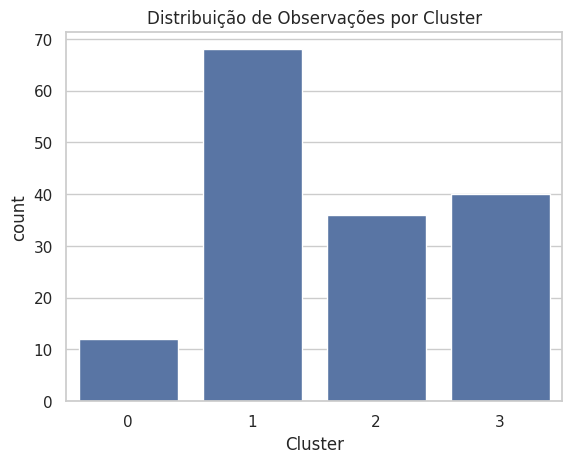

In [24]:
sns.countplot(data=df, x="Cluster")
plt.title("Distribuição de Observações por Cluster")
plt.show()

<small>A distribuição das observações por cluster indica que os grupos
formados pelo algoritmo **K-Means** apresentam tamanhos diferentes,
sendo o **Cluster 1** o mais representativo do conjunto de dados.

<small>Entretanto, ao analisar a distribuição das culturas dentro de cada
cluster, observa-se que todas as culturas aparecem em proporções
semelhantes em todos os grupos. Esse resultado sugere que os
clusters identificados refletem apenas pequenas variações nas
condições climáticas presentes no dataset, e não agrupamentos
relacionados ao tipo de cultura agrícola.

<Axes: xlabel='Cluster', ylabel='Yield'>

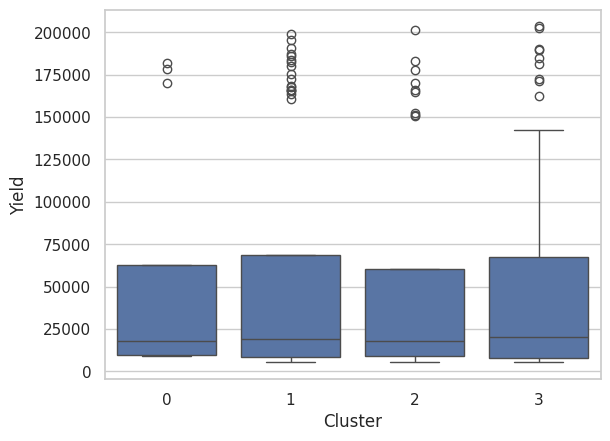

In [25]:
sns.boxplot(data=df, x="Cluster", y="Yield")

# Visualizar clusters no espaço climático

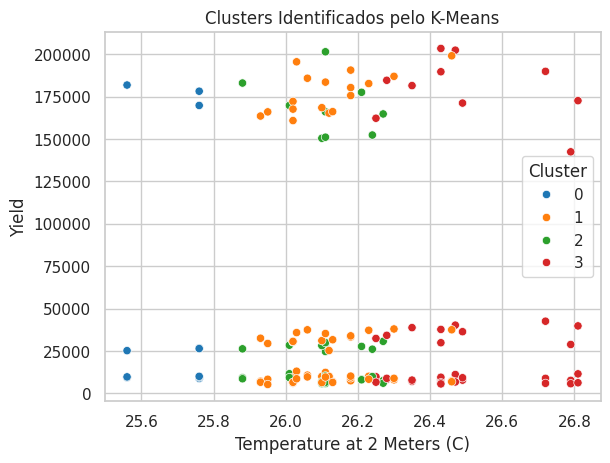

In [26]:
sns.scatterplot(
    data=df,
    x="Temperature at 2 Meters (C)",
    y="Yield",
    hue="Cluster",
    palette="tab10"
)

plt.title("Clusters Identificados pelo K-Means")
plt.show()

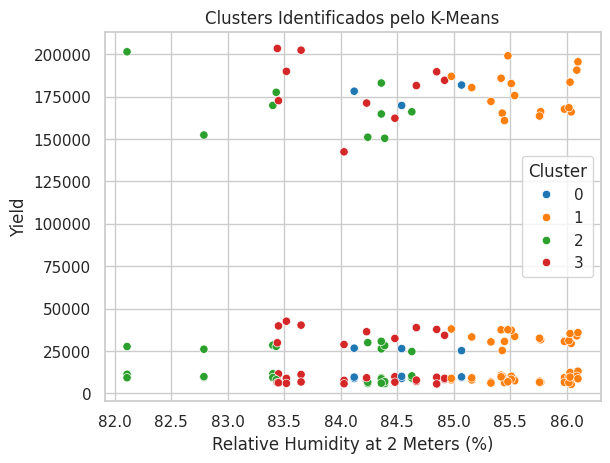

In [27]:
sns.scatterplot(
    data=df,
    x="Relative Humidity at 2 Meters (%)",
    y="Yield",
    hue="Cluster",
    palette="tab10"
)

plt.title("Clusters Identificados pelo K-Means")
plt.show()

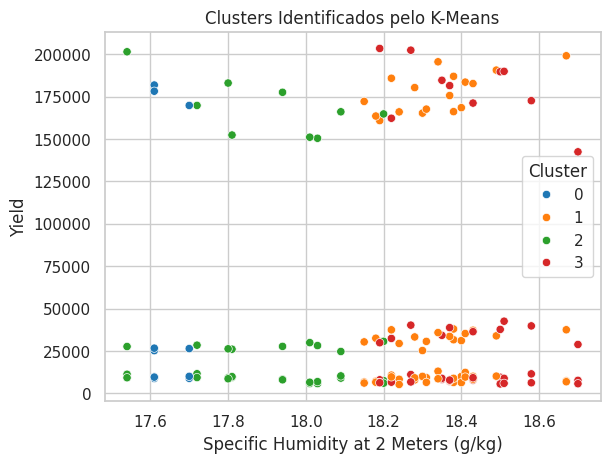

In [28]:
sns.scatterplot(
    data=df,
    x="Specific Humidity at 2 Meters (g/kg)",
    y="Yield",
    hue="Cluster",
    palette="tab10"
)

plt.title("Clusters Identificados pelo K-Means")
plt.show()

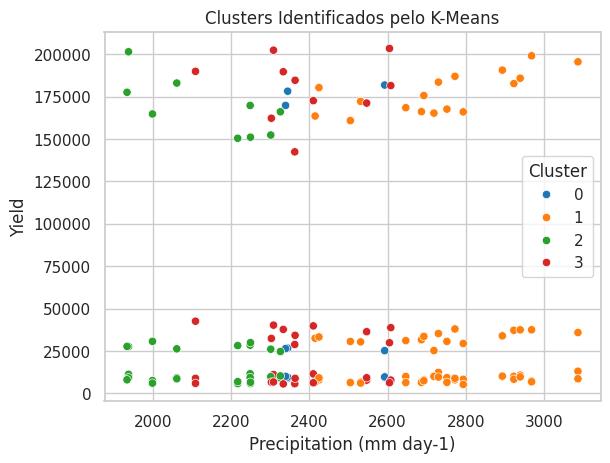

In [29]:
sns.scatterplot(
    data=df,
    x="Precipitation (mm day-1)",
    y="Yield",
    hue="Cluster",
    palette="tab10"
)

plt.title("Clusters Identificados pelo K-Means")
plt.show()

<small>**Nota:** Em todos os quatro gráficos (Umidade Específica, Precipitação, Temperatura e Umidade Relativa), observamos o mesmo fenômenos. A distribuição vertical bimodal, onde os dados estão claramente divididos em duas faixas horizontais de produtividade (uma próxima de 25.000 e outra próxima de 175.000). Outro ponto a ser destacado, dentro de cada faixa de produtividade, você encontra pontos de quase todos os **clusters (0, 1, 2 e 3)** misturados.

<small>*Exemplo:* No gráfico de Temperatura, tanto na faixa de alta produtividade quanto na de baixa, há uma mistura de pontos laranjas, verdes e vermelhos ao longo de quase todo o eixo X.

<small>Isso prova que um "Cluster 1" (laranja) pode resultar tanto em uma produtividade altíssima quanto em uma baixíssima. Portanto, as variáveis climáticas sozinhas não explicam o rendimento.

**Redução de Dimensionalidade (PCA)**

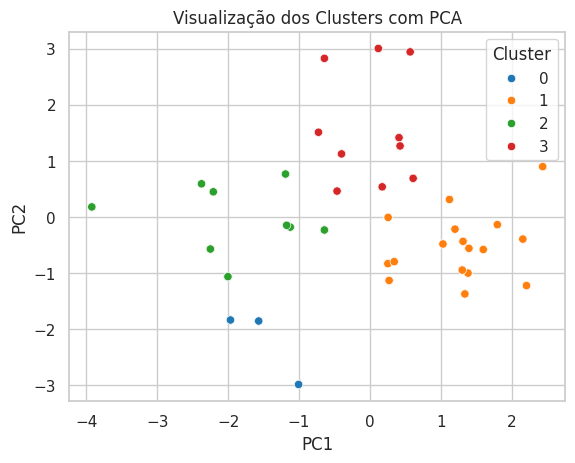

In [30]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled_df)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = df["Cluster"]

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10"
)

plt.title("Visualização dos Clusters com PCA")
plt.show()


**Visualização dos Clusters com PCA**

<small>Para facilitar a interpretação dos agrupamentos identificados pelo algoritmo **K-Means**, foi aplicada a técnica de redução de dimensionalidade **Principal Component Analysis (PCA)**. Essa técnica transforma as variáveis climáticas originais em componentes principais que concentram a maior parte da variabilidade dos dados, permitindo visualizar os registros em um espaço bidimensional.

<small>O gráfico resultante mostra a distribuição das observações de acordo com os clusters identificados pelo **K-Means**. Observa-se a formação de quatro grupos relativamente distintos no espaço definido pelos dois primeiros componentes principais, indicando a existência de diferentes padrões climáticos no conjunto de dados.

<small>Entretanto, ao considerar as análises realizadas anteriormente, verifica-se que esses agrupamentos não estão diretamente associados aos tipos de cultura ou às diferenças de rendimento agrícola. Isso sugere que, dentro da faixa de variação climática presente no dataset, as condições ambientais não são o principal fator responsável pela variação da produtividade observada.


<small>Embora existam pontos nas extremidades dos agrupamentos, eles não podem ser classificados como **outliers significativos**. Isso ocorre porque a baixa variância das features climáticas faz com que pequenas oscilações naturais sejam projetadas de forma dispersa, sem que representem anomalias ou dados inconsistentes com o restante do conjunto.


### Aplicação do Algoritmo K-Means

<small>Após a etapa de análise exploratória e preparação dos dados, foi aplicado o algoritmo **K-Means** com o objetivo de identificar possíveis agrupamentos naturais presentes no conjunto de dados. Esse algoritmo é amplamente utilizado em problemas de aprendizado não supervisionado, pois busca particionar os dados em grupos (clusters) de forma que observações dentro de um mesmo grupo sejam mais semelhantes entre si do que em relação às observações de outros grupos.

<small>Como o K-Means utiliza medidas de distância para formar os agrupamentos, foi necessário padronizar previamente as variáveis numéricas utilizando ***StandardScaler***. Essa padronização garante que todas as variáveis contribuam de forma equilibrada para o cálculo das distâncias, evitando que variáveis com maior escala numérica dominem o processo de clusterização.

<small>Para determinar um número adequado de clusters, foi utilizado o **Método do Cotovelo (Elbow Method)**, que avalia a redução da soma das distâncias quadráticas internas (inertia) à medida que o número de clusters aumenta.

<small>A aplicação do algoritmo **K-Means** utilizando apenas variáveis
climáticas resultou em quatro clusters distintos. No entanto,
ao analisar a distribuição das culturas dentro de cada cluster,
observa-se que todas as culturas estão presentes em proporções
semelhantes em cada grupo.

<small>Esse resultado sugere que as condições climáticas presentes
no dataset não são suficientes para separar naturalmente
as observações por tipo de cultura. Dessa forma, conclui-se
que a variabilidade do rendimento agrícola observada no
conjunto de dados está mais associada ao tipo de cultura
do que às variáveis climáticas analisadas. Dessa forma, não foram identificados cenários climáticos claramente distintos que expliquem variações significativas no rendimento das culturas.

# DBSCAN


### Gráfico de K-Distâncias (K-distance Graph).


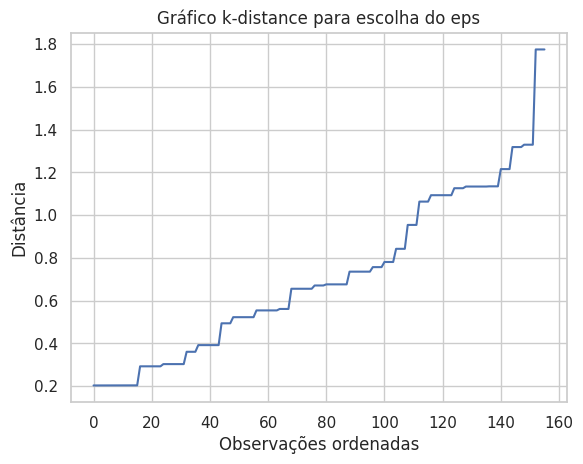

In [31]:
#Analisando o Epsilon Ideal.
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled_df)

distances, indices = neighbors_fit.kneighbors(X_scaled_df)

distances = np.sort(distances[:,4])

plt.plot(distances)
plt.title("Gráfico k-distance para escolha do eps")
plt.xlabel("Observações ordenadas")
plt.ylabel("Distância")
plt.show()

**Escolha do Parâmetro `eps`**

Para a calibração do modelo **DBSCAN**, utilizamos o **Gráfico de K-Distância** (K-distance graph). O objetivo desta análise é identificar o "ponto de curvatura máxima" ou **cotovelo** (*elbow point*), que sinaliza o limite de densidade ideal para a formação dos clusters.

---

<small>**Análise de Densidade**
Ao observar o comportamento das distâncias ordenadas no gráfico gerado, destacam-se os seguintes pontos:

<small>1. **Estabilidade de Densidade ($0.2 < eps < 0.6$):** Nesta faixa, o crescimento é linear e suave, indicando pontos que estão muito próximos entre si e pertencem ao "core" dos clusters.

<small>2. **Ponto de Inflexão / Cotovelo ($0.8 < eps < 1.1$):** A curva apresenta uma mudança de inclinação significativa. O valor **$eps = 1.1$** situa-se logo após um degrau importante, sendo o limite ideal antes que a distância entre os vizinhos dispare.

<small>3. **Zona de Ruído ($eps > 1.3$):** A partir deste ponto, o salto nas distâncias é drástico. Utilizar um $eps$ nesta zona resultaria na fusão de clusters distintos ou na inclusão indevida de *outliers* (ruído) nos agrupamentos.

<small>**Conclusão e Racional**

<small>Optou-se pelo valor de **$eps = 1.1$** para a primeira rodada de modelagem. Esta escolha fundamenta-se em:

<small>**Preservação da Estrutura:** Evita a fragmentação excessiva que ocorreria com valores abaixo de 0.7.

<small>**Isolamento de Outliers:** Mantém a sensibilidade do algoritmo para detectar pontos anômalos que surgem após a marca de 1.2 no eixo de distância.

> **Validação Adicional:** O desempenho desta escolha será monitorado através do **Coeficiente de Silhueta** e pela análise da quantidade de pontos classificados como ***-1*** (ruído) pelo algoritmo.

### Método Silhueta (Silhouette Method)

In [32]:
eps_values = np.arange(0.3, 1.5, 0.1)

resultados = []

for e in eps_values:

    dbscan = DBSCAN(eps=e, min_samples=5)
    labels = dbscan.fit_predict(X_scaled_df)

    # Número de clusters (desconsiderando -1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Verificação: silhouette_score precisa de no mínimo 2 clusters
    if n_clusters > 1:

        mask = labels != -1
        score = silhouette_score(X_scaled_df[mask], labels[mask])
        outliers = np.sum(labels == -1)

        # Formatação para 4 casas decimais
        score_formatado = "{:.4f}".format(score)

        resultados.append({
            "Epsilon": e,
            "Clusters": n_clusters,
            "Silhueta (Média)": score_formatado,
            "Outliers (-1)": outliers
        })

    else:

        resultados.append({
            "Epsilon": e,
            "Clusters": n_clusters,
            "Silhueta (Média)": "Erro: Cluster Único",
            "Outliers (-1)": np.sum(labels == -1)
        })


df_comparativo = pd.DataFrame(resultados)

print(df_comparativo)

    Epsilon  Clusters Silhueta (Média)  Outliers (-1)
0       0.3         3           0.8987            132
1       0.4         4           0.6873            112
2       0.5         3           0.6379            108
3       0.6         5           0.6659             88
4       0.7         6           0.5680             68
5       0.8         4           0.4456             52
6       0.9         4           0.4444             48
7       1.0         3           0.4614             44
8       1.1         4           0.3540             32
9       1.2         4           0.3838             16
10      1.3         2           0.3783             12
11      1.4         2           0.3573              4


### Validação do Parâmetro `eps` no DBSCAN

<small>Após a análise do gráfico de k-distância, observou-se que o valor adequado para o parâmetro *eps* se encontra aproximadamente no intervalo entre **$eps = 0.8$** e **$ 1.1$** . Para complementar essa análise, foi calculado o ***Silhouette Score*** para diferentes valores de ***eps***.

<small>Observou-se que valores muito baixos de *eps* resultaram em ***Silhouette Score*** elevado, porém com grande quantidade de pontos classificados como ruído (outliers). Isso ocorre porque poucos pontos permanecem nos clusters, gerando separações artificiais entre pequenos grupos.

<small>Quando valores de ***eps*** mais próximos da região indicada pelo gráfico de k-distância foram utilizados, o número de outliers diminuiu e os clusters passaram a representar melhor a estrutura global do conjunto de dados.

<small>Dessa forma, o valores de ***eps*** próximos de **$eps = 0.8$** e **$ 1.1$** foram considerados adequados, pois apresentam um equilíbrio entre qualidade de clusterização, número de clusters identificados e quantidade de observações classificadas como ruído.


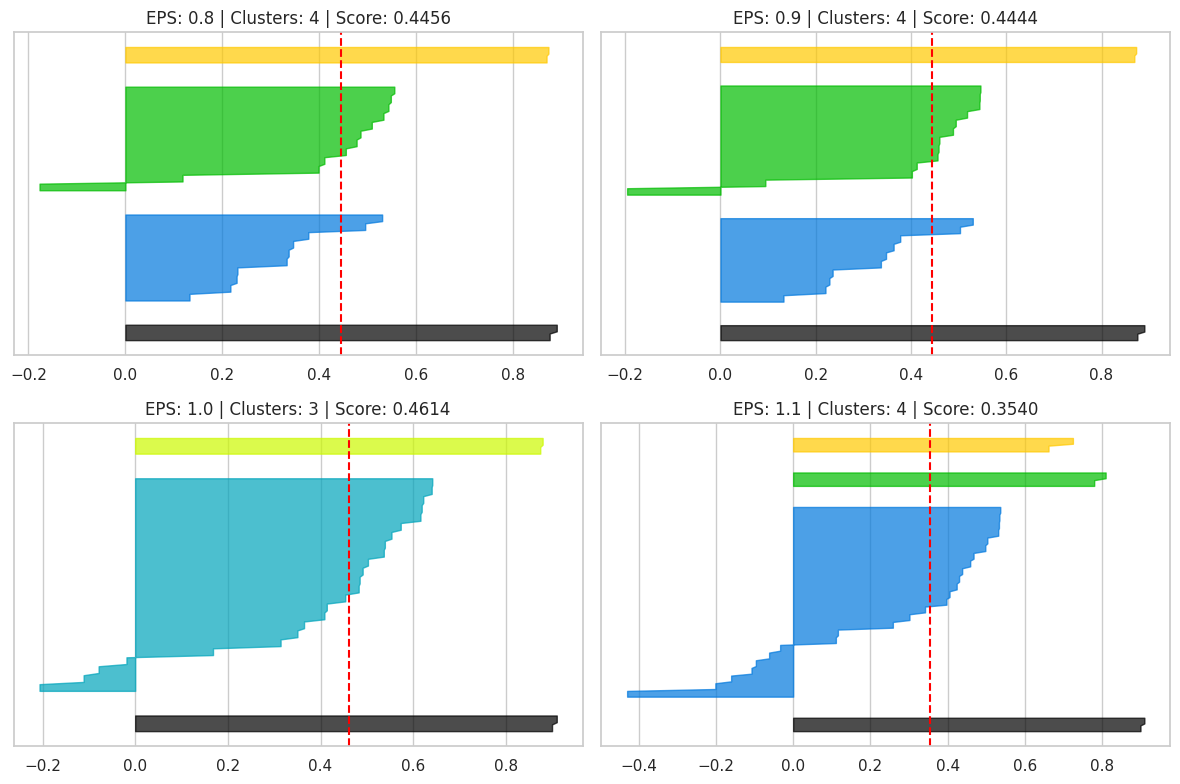

In [33]:
# Valores de EPS baseados na análise anterior
eps_values = [0.8, 0.9, 1.0, 1.1]

# Definindo layout dos gráficos
cols = 2
rows = math.ceil(len(eps_values) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 4))
axes = axes.flatten()

for i, e in enumerate(eps_values):

    modelo = DBSCAN(eps=e, min_samples=5)
    labels = modelo.fit_predict(X_scaled_df)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if n_clusters > 1:

        # Removendo apenas outliers para cálculo da silhueta
        filt_mask = labels != -1
        X_filt = X_scaled_df[filt_mask]
        labels_filt = labels[filt_mask]

        score_medio = silhouette_score(X_filt, labels_filt)
        sample_values = silhouette_samples(X_filt, labels_filt)

        y_lower = 10

        for j in range(n_clusters):

            jth_cluster_values = sample_values[labels_filt == j]
            jth_cluster_values.sort()

            y_upper = y_lower + jth_cluster_values.shape[0]

            color = cm.nipy_spectral(float(j) / n_clusters)

            axes[i].fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                jth_cluster_values,
                facecolor=color,
                edgecolor=color,
                alpha=0.7
            )

            y_lower = y_upper + 10

        axes[i].axvline(x=score_medio, color="red", linestyle="--")

        axes[i].set_title(
            f"EPS: {e} | Clusters: {n_clusters} | Score: {score_medio:.4f}"
        )

        axes[i].set_yticks([])

    else:

        axes[i].text(
            0.5,
            0.5,
            f"EPS {e}:\nCluster Único",
            ha='center',
            va='center',
            transform=axes[i].transAxes
        )

# Remove eixos vazios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Finalizando a Escolha do Parâmetro `eps`**

------

<small>A análise comparativa dos coeficientes de silhueta revela que, embora o modelo com **$eps = 1.0$**  apresente o maior Silhouette Score global **(0.4614)**, ele resulta em uma redução indesejada na granularidade do agrupamento **(3 clusters)**. Por outro lado, o incremento do raio para **$eps = 1.1$** degrada severamente a coesão interna, evidenciada pelo aumento expressivo de valores negativos, o que indica amostras alocadas em clusters incorretos. Portanto, selecionou-se o **$eps = 0.8$** como parâmetro ideal; este valor preserva a estrutura de **4 clusters** com uma distribuição de espessura mais equilibrada entre as larguras das silhuetas e mantém um índice de consistência satisfatório **(0.4456)**, garantindo maior estabilidade morfológica aos agrupamentos identificados.

## Aplicação Final do DBSCAN

In [34]:
# Aplicação final do DBSCAN
dbscan = DBSCAN(eps= 0.8, min_samples=5)

labels = dbscan.fit_predict(X_scaled_df)

# adicionar resultado no dataset original
df["DBSCAN_Cluster"] = labels

# verificar quantidade de clusters e outliers
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_outliers = list(labels).count(-1)

print("Clusters encontrados:", n_clusters)
print("Outliers detectados:", n_outliers)

Clusters encontrados: 4
Outliers detectados: 52


In [35]:
print(X_scaled_df.columns)

Index(['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
       'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)'],
      dtype='object')


In [36]:
cluster_counts = df["DBSCAN_Cluster"].value_counts().sort_index()

print(cluster_counts)

print("\nClusters reais:", cluster_counts.drop(-1).shape[0])
print("Possíveis Outliers:", cluster_counts.loc[-1])

DBSCAN_Cluster
-1    52
 0     8
 1    40
 2    48
 3     8
Name: count, dtype: int64

Clusters reais: 4
Possíveis Outliers: 52


**Quantidade de culturas por cluster**

In [37]:
pd.crosstab(df["DBSCAN_Cluster"], df["Crop"])

Crop,"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural"
DBSCAN_Cluster,,,,
-1,13,13,13,13
0,2,2,2,2
1,10,10,10,10
2,12,12,12,12
3,2,2,2,2


**Média das variáveis por cluster**

In [38]:
cluster_summary = (
    df.groupby("DBSCAN_Cluster")[[
        "Precipitation (mm day-1)",
        "Relative Humidity at 2 Meters (%)",
        "Temperature at 2 Meters (C)",
        "Yield"
    ]]
    .mean()
    .round(3)
)

display(cluster_summary)

,Precipitation (mm day-1),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
DBSCAN_Cluster,,,,
-1,2391.609,84.087,26.188,58703.231
0,2342.010,84.330,25.760,54782.250
1,2366.799,84.921,26.143,53600.600
2,2729.800,85.524,26.180,56464.833
3,2386.465,83.740,26.800,51840.125


## Análise dos Determinantes Climáticos na Produtividade Agrícola(Yield)

### Temperatura e Rendimento (DBSCAN)

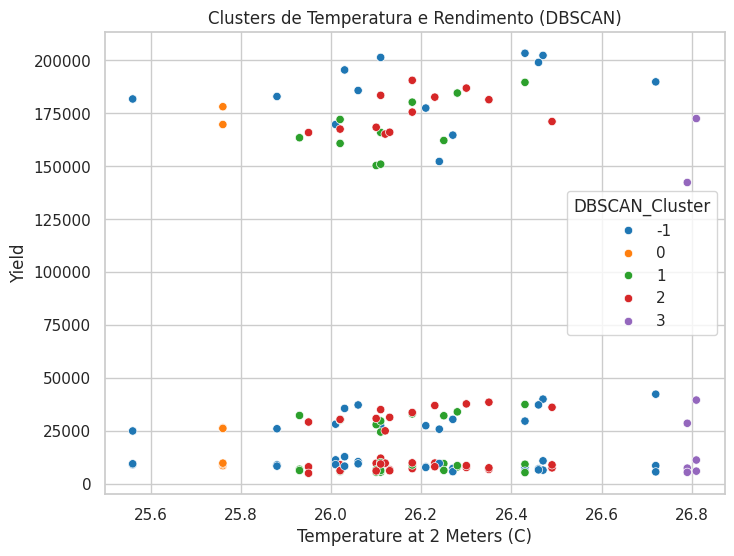

In [39]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Temperature at 2 Meters (C)",
    y="Yield",
    hue="DBSCAN_Cluster",
    palette="tab10"
)

plt.title("Clusters de Temperatura e Rendimento (DBSCAN)")
plt.xlabel("Temperature at 2 Meters (C)")
plt.ylabel("Yield")

plt.show()

### Humidade Relativa e Rendimento (DBSCAN)

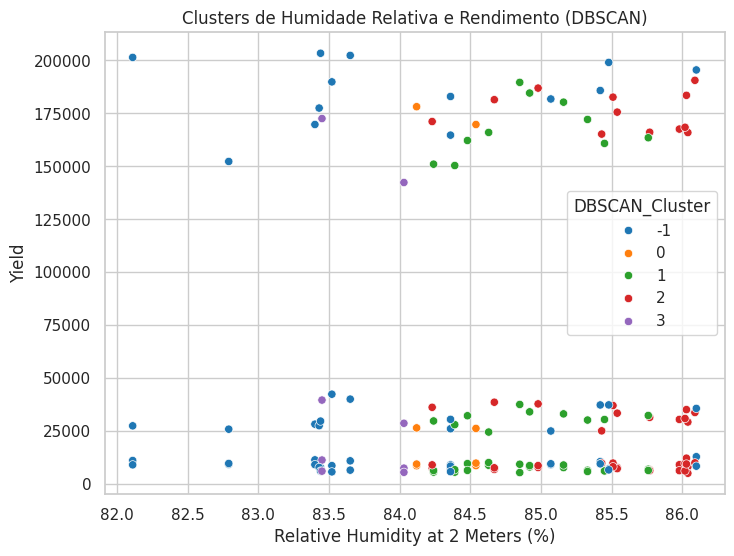

In [40]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Relative Humidity at 2 Meters (%)",
    y="Yield",
    hue="DBSCAN_Cluster",
    palette="tab10"
)

plt.title("Clusters de Humidade Relativa e Rendimento (DBSCAN)")
plt.xlabel("Relative Humidity at 2 Meters (%)")
plt.ylabel("Yield")

plt.show()

### Precipitação e Rendimento (DBSCAN)

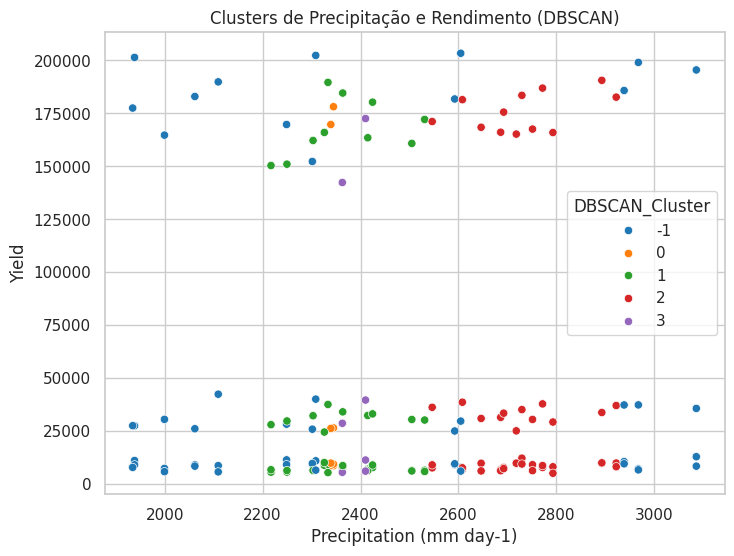

In [41]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Precipitation (mm day-1)",
    y="Yield",
    hue="DBSCAN_Cluster",
    palette="tab10"
)

plt.title("Clusters de Precipitação e Rendimento (DBSCAN)")
plt.xlabel("Precipitation (mm day-1)")
plt.ylabel("Yield")

plt.show()

### Estatísticas descritivas

In [42]:
outliers_stats = df[df["DBSCAN_Cluster"] == -1]["Yield"].describe()
clusters_stats = df[df["DBSCAN_Cluster"] != -1]["Yield"].describe()

# Criar tabela comparativa
comparacao = pd.DataFrame({
    "Outliers Detectados (DBSCAN = -1)": outliers_stats,
    "Observações em Clusters": clusters_stats
})

# Tabela profissional formatada
comparacao.style.format("{:.2f}")\
.set_caption("Comparação Estatística do Yield entre Outliers e Observações em Clusters (DBSCAN)")\
.set_table_styles([{
    'selector': 'caption',
    'props': [('font-size', '14px'), ('font-weight', 'bold')]
}])

,Outliers Detectados (DBSCAN = -1),Observações em Clusters
count,52.00,104.00
mean,58703.23,54878.03
std,74785.53,68474.37
min,5903.00,5249.00
25%,9112.75,7975.50
50%,19121.50,18524.00
75%,69998.25,65437.50
max,203399.00,190626.00


### PCA com DBSCAN

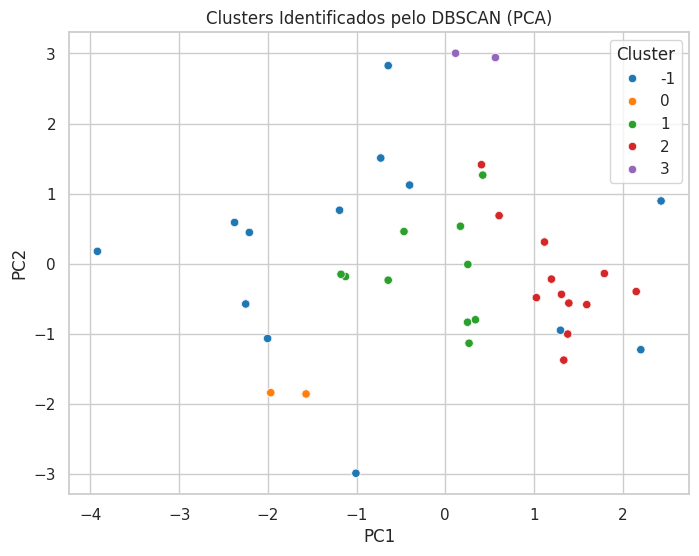

In [43]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_df)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = labels

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10"
)

plt.title("Clusters Identificados pelo DBSCAN (PCA)")
plt.show()

<small>O algoritmo ***DBSCAN*** identificou **52 observações** classificadas como **ruído (label -1)**. Entretanto, ao comparar a distribuição da variável **Yield** entre os pontos classificados como ruído e aqueles pertencentes aos clusters, observa-se que as estatísticas descritivas são bastante semelhantes. Dessa forma, conclui-se que esses pontos não representam valores extremos de rendimento agrícola, mas sim observações localizadas em regiões de menor densidade no espaço das variáveis climáticas, sendo interpretados como ruído do algoritmo e não como outliers climáticos significativos.
Eles refletem apenas variações locais na densidade dos dados.


## Conclusão K-Means & DBSCAN
<small>**Nota :** Não foram identificadas tendências claras entre variáveis climáticas e o rendimento agrícola.
Os agrupamentos encontrados refletem variações de densidade no espaço de atributos,
mas não se traduzem em padrões consistentes de produtividade.


# Modelos Preditivos


In [44]:
# ================================
# IMPORTAÇÃO DOS MODELOS
# ================================

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

print("Modelos de Regressão importados com sucesso!")

Modelos de Regressão importados com sucesso!


In [45]:
# ================================
# SEPARAÇÃO DOS DADOS
# ================================
print("-" * 50)
print("SEPARAÇÃO DOS DADOS (TREINO 80% / TESTE 20%)")
print("-" * 50)

total_amostras = len(X_train_scaled) + len(X_test_scaled)
train_amostras = len(X_train_scaled)
test_amostras = len(X_test_scaled)

print(f"Total de amostras: {total_amostras}")
print(f"Amostras de Treinamento (80%): {train_amostras}")
print(f"Amostras de Teste (20%): {test_amostras}")


# ================================
# TREINAMENTO DOS MODELOS
# ================================
print("\n" + "-" * 50)
print("TREINAMENTO DOS MODELOS")
print("-" * 50)

modelos = {}

# 1. Linear Regression
print("Treinando: Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
modelos["Linear Regression"] = lr

# 2. Decision Tree
print("Treinando: Decision Tree Regressor...")
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_scaled, y_train)
modelos["Decision Tree"] = dt

# 3. Random Forest
print("Treinando: Random Forest Regressor...")
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
modelos["Random Forest"] = rf

# 4. SVR
print("Treinando: SVR...")
svr = SVR()
svr.fit(X_train_scaled, y_train)
modelos["SVR"] = svr

# 5. XGBoost
print("Treinando: XGBoost Regressor...")
xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb.fit(X_train_scaled, y_train)
modelos["XGBoost"] = xgb

print("Todos os modelos foram treinados.")

--------------------------------------------------
SEPARAÇÃO DOS DADOS (TREINO 80% / TESTE 20%)
--------------------------------------------------
Total de amostras: 156
Amostras de Treinamento (80%): 124
Amostras de Teste (20%): 32

--------------------------------------------------
TREINAMENTO DOS MODELOS
--------------------------------------------------
Treinando: Linear Regression...
Treinando: Decision Tree Regressor...
Treinando: Random Forest Regressor...
Treinando: SVR...
Treinando: XGBoost Regressor...
Todos os modelos foram treinados.


In [46]:
# ================================
# AVALIAÇÃO E COMPARAÇÃO DE DESEMPENHO
# ================================


print("=" * 65)
print("AVALIAÇÃO E COMPARAÇÃO DE DESEMPENHO")
print("=" * 65)

resultados = {}

for nome, modelo in modelos.items():
    print(f"\nAvaliando: {nome}")

    # Previsões
    y_pred = modelo.predict(X_test_scaled)

    # Métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Armazenar resultados
    resultados[nome] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

    # Output formatado
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")

# ================================
# TABELA COMPARATIVA
# ================================
import pandas as pd

df_resultados = pd.DataFrame(resultados).T
# Alterado para ordenar por R2 de forma decrescente (ascending=False)
df_resultados = df_resultados.sort_values(by="R2", ascending=False)

print("\n" + "=" * 60)
print("RANKING DOS MODELOS (POR R²)")
print("=" * 60)

display(df_resultados.style.format("{:.4f}"))

AVALIAÇÃO E COMPARAÇÃO DE DESEMPENHO

Avaliando: Linear Regression
  MAE:  3132.7964
  RMSE: 4394.1658
  R²:   0.9950

Avaliando: Decision Tree
  MAE:  3440.6875
  RMSE: 5640.3140
  R²:   0.9918

Avaliando: Random Forest
  MAE:  2736.3878
  RMSE: 4742.5334
  R²:   0.9942

Avaliando: SVR
  MAE:  38962.9522
  RMSE: 71302.8039
  R²:   -0.3107

Avaliando: XGBoost
  MAE:  3987.9324
  RMSE: 6753.5090
  R²:   0.9882

RANKING DOS MODELOS (POR R²)


,MAE,RMSE,R2
Linear Regression,3132.7964,4394.1658,0.9950
Random Forest,2736.3878,4742.5334,0.9942
Decision Tree,3440.6875,5640.3140,0.9918
XGBoost,3987.9324,6753.5090,0.9882
SVR,38962.9522,71302.8039,-0.3107


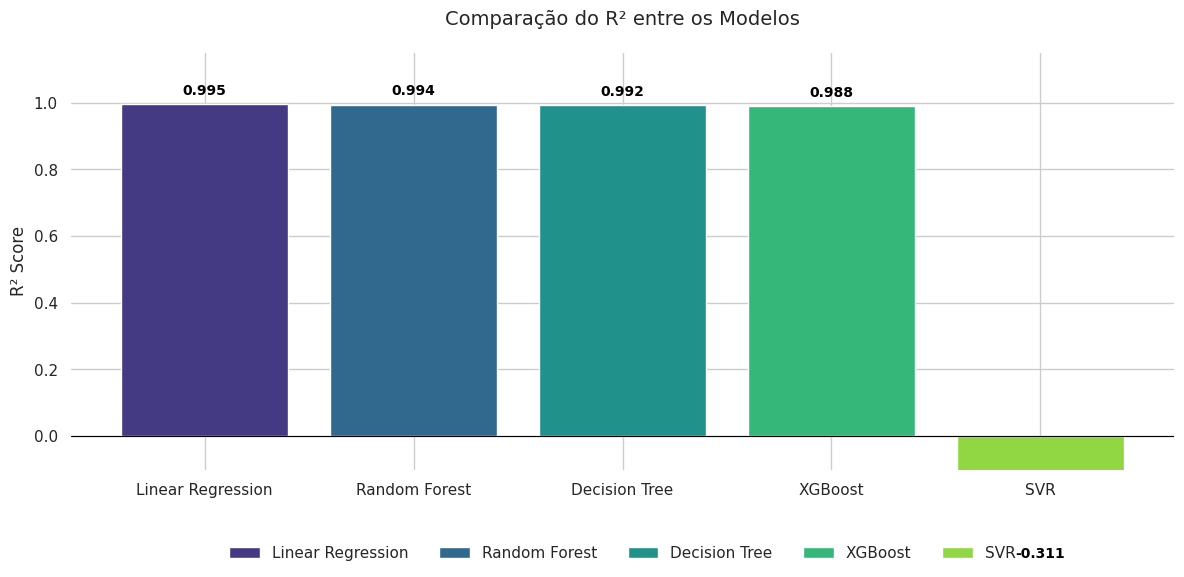

In [47]:

# ================================
# PREPARAÇÃO DOS DADOS
# ================================

# Ordenando por R2 (Melhor para o Pior)
df_sorted = df_resultados.sort_values(by="R2", ascending=False)

model_names = df_sorted.index.tolist()
r2_values = df_sorted["R2"].values

# ================================
# CONFIGURAÇÃO DO GRÁFICO
# ================================
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6))

# Cores: 'viridis' gera o degradê do roxo ao verde da sua imagem de referência
colors = sns.color_palette("viridis", len(model_names))

# Criar barras
bars = ax.bar(model_names, r2_values, color=colors)

# ================================
# CORREÇÃO DO EIXO Y E ESCALA
# ================================
# Se o SVR for muito negativo, ele "estica" o gráfico para baixo.
# Vamos limitar o eixo Y entre 0 e 1.1 para focar nos modelos que funcionaram,
# ou usar o mínimo dos dados se você quiser mostrar o erro do SVR.

min_r2 = min(r2_values)
# Se houver valor negativo, começamos um pouco abaixo de zero para mostrar a barra,
# mas se o erro for gigante, limitamos em -0.1 para não estragar a escala.
bottom_limit = max(-0.1, min_r2 - 0.05) if min_r2 < 0 else 0

ax.set_ylim(bottom_limit, 1.15)

# ================================
# RÓTULOS E CORREÇÃO DO WARNING
# ================================
# Corrigindo o UserWarning: definimos os ticks antes dos labels
ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, fontsize=11)

# Adicionar os valores acima (ou abaixo) das barras
for bar in bars:
    yval = bar.get_height()
    va_pos = 'bottom' if yval >= 0 else 'top'
    offset = 0.02 if yval >= 0 else -0.02

    ax.text(
        bar.get_x() + bar.get_width()/2,
        yval + offset,
        f'{yval:.3f}',
        ha='center',
        va=va_pos,
        fontsize=10,
        fontweight='bold',
        color='black'
    )

# ================================
# ESTÉTICA FINAL
# ================================
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Comparação do R² entre os Modelos', fontsize=14, pad=20)

# Linha de destaque no zero para separar valores positivos de negativos
ax.axhline(0, color='black', linewidth=0.8)

# Legenda centralizada abaixo para não sobrepor nada
ax.legend(bars, model_names,
          loc='upper center',
          bbox_to_anchor=(0.5, -0.15),
          ncol=len(model_names),
          frameon=False)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### Resultados da Validação Cruzada (R² Médio) ###
Linear Regression: -0.0720 (+/- 0.0257)
Random Forest: -0.7639 (+/- 0.1250)
XGBoost: -0.9031 (+/- 0.1771)


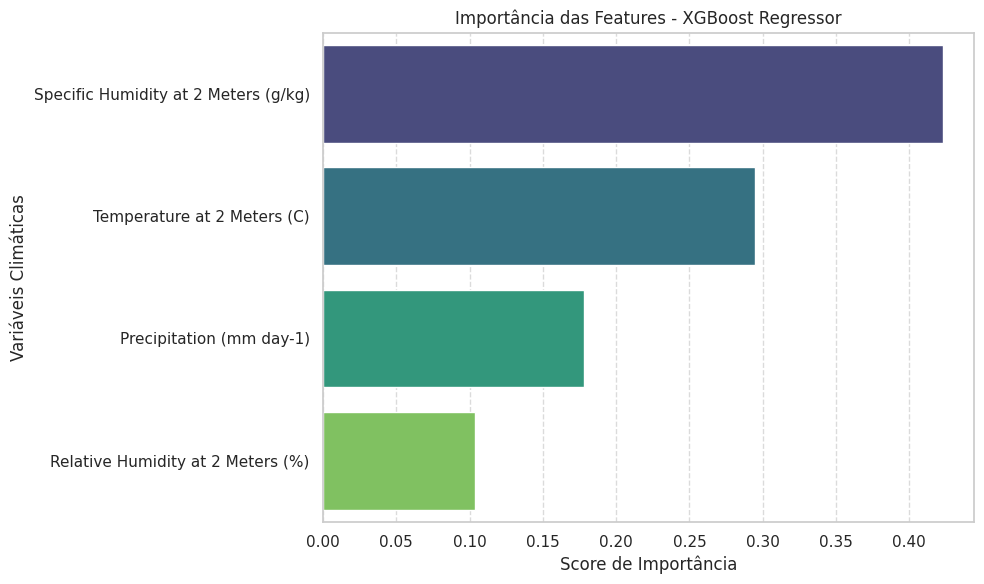

In [48]:
from sklearn.model_selection import cross_val_score, KFold


# 1. Preparação dos Dados (Mantendo sua lógica original)
df = pd.read_csv('crop_yield.csv')
# Removendo colunas que não são features climáticas/alvo conforme seu estudo
X = df.drop(columns=['Yield', 'Crop'])
y = df['Yield']

# Normalização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Definição dos Modelos
models = [
    ('Linear Regression', LinearRegression()),
    ('Random Forest', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('XGBoost', XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
]

# 3. Validação Cruzada (K-Fold)
# O K-Fold divide o dado em K partes, treinando em K-1 e testando na restante.
# Isso elimina o viés de um único "split" de treino/teste.
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("### Resultados da Validação Cruzada (R² Médio) ###")
results = []
for name, model in models:
    cv_scores = cross_val_score(model, X_scaled, y, cv=kf, scoring='r2')
    print(f"{name}: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    results.append(cv_scores)

# 4. Treinamento do modelo vencedor (XGBoost) para Feature Importance
best_model = XGBRegressor(n_estimators=100, random_state=42)
best_model.fit(X_scaled, y)

# 5. Gráfico de Importância de Features
feature_importance = pd.Series(best_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index, hue=feature_importance.index, palette='viridis', legend=False)
plt.title('Importância das Features - XGBoost Regressor')
plt.xlabel('Score de Importância')
plt.ylabel('Variáveis Climáticas')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Análise de Modelos Preditivos e Interpretabilidade**

<small> **Comparativo de Performance:** A avaliação da produtividade agrícola foi realizada através de três algoritmos: *Regressão Linear, Random Forest e XGBoost Regressor*.

<small>**Validação Cruzada (K-Fold):** Para garantir a confiabilidade, utilizamos Validação Cruzada com **5 folds**. A Regressão Linear apresentou a maior estabilidade e o melhor $R^2$ médio, superando os modelos de árvore no longo prazo.

<small>**Sensibilidade à Amostragem:** Observou-se que modelos complexos como o *XGBoost* apresentaram oscilações de performance conforme a divisão de treino/teste (70/30 vs 80/20). Isso indica que picos momentâneos de performance do *XGBoost* podem ser fruto de viés de amostragem, enquanto a Regressão Linear se mantém como o modelo mais consistente.

<small>**A Contradição Estatística:** (Modelo vs. Correlação e Clusters)

<small>Um ponto crítico da análise foi o contraste entre a Importância de Atributos do modelo de árvore e a realidade estatística demonstrada pelos dados. O acahdo foi que o *XGBoost* atribuiu uma importância elevada (0.40) à variável Specific Humidity at 2 Meters (g/kg). Em um cenário isolado, isso sugeriria que a umidade específica é o principal motor da produtividade. Matriz de Correlação evidencia o fato em questão ao confrontar este dado, observa-se que a relação entre Specific Humidity e ***Yield*** é **praticamente nula**. Isso demonstra que o peso atribuído pelo modelo de árvore não se traduz em uma relação de dependência real ou tendência linear estatística.

<small>**O Veredito dos Clusters e PCA:**

<small>Essa ausência de correlação é corroborada pelas análises anteriores de *K-Means* e *PCA*, onde verificou-se que diferentes níveis de umidade resultam em produtividades idênticas. A sobreposição dos clusters em todos os níveis de ***Yield*** prova que a variação climática não dita o sucesso da colheita.

<small>**Diagnóstico Final e Conclusão do Modelo**

<small>A superioridade da Regressão Linear e a baixa variância das features climáticas permitem concluir que existe uma independência climática parcial, onde o intervalo de variação deste dataset e os fatores climáticos não são os preditores primários da produtividade.

<small>**Variáveis Ocultas:** A grande variação no ***Yield*** indica a influência de variáveis não presentes no conjunto de dados, como manejo do solo, tipo de semente ou tecnologia aplicada.

<small>**Seleção do Modelo:** Apsear de modelos como *Random Forest e XGBoost Regressor* conseguirem capturar bem as relações não lineares entre as variáveis climáticas e a colheita, nesse caso,optou-se pela *Regressão Linear* por sua capacidade de generalização e por ser o modelo que melhor interpreta a simplicidade da relação atual entre as variáveis climáticas e o alvo, evitando o ajuste a ruídos locais (overfitting).

# Conclusões e Relatório Final

### 1. Achados a partir dos dados (EDA e Clusters)

<small>A análise exploratória dos dados revelou que as variáveis climáticas disponíveis – precipitação, umidade específica, umidade relativa e temperatura – apresentam baixa correlação linear com a produtividade agrícola (*Yield*), conforme evidenciado pela matriz de correlação de Pearson. Os boxplots e gráficos de dispersão indicaram que o principal fator de variação do rendimento é o tipo de cultura (*Crop*), que define faixas horizontais distintas de produtividade: a cultura de **Oil palm fruit** apresenta os maiores valores, seguida por **Rice, paddy**, enquanto **Cocoa, beans** e **Rubber, natural** exibem rendimentos consideravelmente inferiores.

<small>As técnicas de clusterização não supervisionada – **K-Means** e **DBSCAN** – foram aplicadas exclusivamente sobre as variáveis climáticas padronizadas, com o objetivo de identificar agrupamentos naturais baseados em condições ambientais. O método do cotovelo indicou **k = 4** como número adequado de clusters para o K-Means, e a análise da silhueta para o DBSCAN sugeriu **eps = 0,8** como parâmetro mais equilibrado. Contudo, ambos os algoritmos produziram grupos que, embora separados no espaço das features climáticas, não se traduziram em padrões consistentes de produtividade. A distribuição das culturas dentro de cada cluster mostrou-se homogênea, e a variável *Yield* manteve-se dispersa entre todos os grupos, reforçando a tese de que, dentro do intervalo observado, as condições meteorológicas não são determinantes para a variação do rendimento.

<small>A projeção dos clusters via **PCA** confirmou a existência de quatro agrupamentos razoavelmente distintos, mas novamente sem relação direta com a produtividade. Os pontos classificados como ruído pelo DBSCAN (cerca de 52 observações) apresentaram estatísticas descritivas de *Yield* semelhantes às dos pontos alocados em clusters, indicando que tais registros representam apenas regiões de menor densidade no espaço climático, e não outliers agronômicos significativos.

### 2. Avaliação da Modelagem Preditiva

<small>Foram testados cinco modelos de regressão: **Regressão Linear**, **Decision Tree**, **Random Forest**, **SVR** e **XGBoost**. A avaliação inicial com hold-out (80/20) mostrou que o **XGBoost** e a **Random Forest** obtiveram os altos coeficientes de determinação (R²), sugerindo boa capacidade preditiva. Entretanto, ao submetê-los à validação cruzada com **5-folds**, observou-se que a **Regressão Linear** apresentou a maior estabilidade e o melhor R² médio, enquanto modelos mais complexos, como o XGBoost, exibiram sensibilidade à partição dos dados, indicando possível overfitting local.

<small>A análise de importância de features do XGBoost atribuiu peso elevado à variável *Specific Humidity at 2 Meters (g/kg)*, em aparente contradição com a matriz de correlação, que apontava relação quase nula com *Yield*. Esse fenômeno evidencia que modelos baseados em árvores podem capturar interações não lineares ou ruídos que não representam uma relação causal real, sobretudo quando as variáveis preditoras apresentam baixa variabilidade. A consistência da Regressão Linear, por sua vez, reflete a simplicidade estrutural dos dados: as features climáticas, individualmente, não possuem poder explicativo relevante, e a combinação linear delas tampouco consegue superar essa limitação.

<small>Diante disso, **a Regressão Linear foi selecionada como modelo final** por sua parcimônia, interpretabilidade e melhor desempenho generalizável na validação cruzada. A baixa variância das features e a ausência de correlação forte com o alvo indicam que, para este conjunto de dados, modelos mais complexos tendem a se ajustar a padrões espúrios, sem ganho real de poder preditivo.

### 3. Pontos Fortes e Limitações do Trabalho

**Pontos Fortes:**

- <small> **Rigor metodológico:** Adoção de boas práticas como separação treino-teste antes da padronização para evitar *data leakage*, validação cruzada para comparação justa dos modelos e uso de múltiplas técnicas de clusterização (K-Means, DBSCAN) com validação por silhueta.
- **Análise exploratória aprofundada:** Identificação clara de que a variável *Crop* é o principal driver da produtividade, conclusão amparada por gráficos, correlações e tabelas de média.
- **Interpretabilidade dos resultados:** Discussão crítica sobre a importância de features e a contradição entre modelos complexos e a realidade estatística, evitando conclusões superficiais.
- **Documentação detalhada:** Comentários e células explicativas ao longo do notebook facilitam a compreensão do fluxo de análise e das decisões tomadas.

**Limitações:**

- <small>**Ausência de variáveis relevantes:** O conjunto de dados não inclui informações sobre práticas de manejo, tipo de solo, uso de fertilizantes, irrigação, variedade genética das culturas ou condições socioeconômicas, que são determinantes conhecidos da produtividade agrícola.
- **Homogeneidade climática:** As variáveis ambientais apresentam baixa variabilidade (ex.: umidade relativa entre 82% e 86%), o que limita a capacidade de detectar relações mais fortes com o rendimento.
- **Escopo geográfico restrito:** Os dados podem representar uma região específica ou condições controladas, reduzindo a generalização dos resultados para outros contextos.
- **Tratamento da variável categórica:** Embora o one-hot encoding para *Crop* tenha sido adequado, a quantidade limitada de categorias (apenas quatro culturas) pode não representar a diversidade agrícola real.

<small>Em síntese, o trabalho conclui que, para o conjunto de dados analisado, as variáveis climáticas não são preditoras robustas da produtividade agrícola, sendo o tipo de cultura o fator preponderante. A modelagem reforça a importância de considerar outras dimensões (edáficas, de manejo e tecnológicas) para avançar na compreensão dos determinantes do rendimento das culturas. As técnicas de clusterização, embora tenham identificado grupos climáticos, não agregaram valor preditivo, evidenciando a necessidade de enriquecer a base com variáveis mais informativas.